<a href="https://colab.research.google.com/github/UBM-ML/artificial-neural-network-team-gerald/blob/main/01_single_layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Varian 01 — Single Layer (Baseline Linier)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/01_single_layer.ipynb)

**Anggota yang mengerjakan:** _Anggota 1_

---

## 🏗️ Arsitektur
Single-layer network: **input langsung ke output**, tanpa hidden layer. Ini setara dengan logistic regression multi-kelas (sesuai sub-bab 2.2 di slide).

## ⚡ Fungsi Aktivasi
Tidak ada fungsi aktivasi di hidden layer (karena tidak ada hidden layer). Output layer menggunakan **softmax** untuk klasifikasi 3 kelas.

## 🎯 Goal
Menjalankan eksperimen ini, menyimpan history training, lalu commit notebook ini (dengan output yang sudah ter-render) ke repo GitHub kelompok.


## 1. Setup environment

In [1]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-team-gerald.git'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Cloning into 'repo'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 30 (delta 6), reused 0 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (30/30), 23.92 KiB | 4.78 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/repo
Working dir: /content/repo
Contents: ['requirements.txt', 'docs', '02_mlp_sigmoid.ipynb', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github']


## 2. Import library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 3. Load data
Catatan: data sudah otomatis di-split, di-shuffle, dan dinormalisasi sesuai konfigurasi bersama di `src/config.py`. **Jangan diubah** supaya perbandingan adil.

In [3]:
X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


## 4. Bangun model

In [4]:
model = Sequential([
    Input(shape=(n_features,)),
    Dense(n_classes, activation='softmax'),  # langsung ke output
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Latih model
Hyperparameter (epochs, batch_size, optimizer) diambil dari `src/config.py` supaya identik dengan varian lain.

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)


Epoch 1/100
12/12 - 1s - 82ms/step - accuracy: 0.2188 - loss: 2.0837 - val_accuracy: 0.1667 - val_loss: 1.9985
Epoch 2/100
12/12 - 0s - 8ms/step - accuracy: 0.2188 - loss: 2.0308 - val_accuracy: 0.1667 - val_loss: 1.9549
Epoch 3/100
12/12 - 0s - 8ms/step - accuracy: 0.2188 - loss: 1.9789 - val_accuracy: 0.1667 - val_loss: 1.9119
Epoch 4/100
12/12 - 0s - 8ms/step - accuracy: 0.2188 - loss: 1.9278 - val_accuracy: 0.1250 - val_loss: 1.8695
Epoch 5/100
12/12 - 0s - 9ms/step - accuracy: 0.2188 - loss: 1.8775 - val_accuracy: 0.1250 - val_loss: 1.8277
Epoch 6/100
12/12 - 0s - 8ms/step - accuracy: 0.2292 - loss: 1.8281 - val_accuracy: 0.1250 - val_loss: 1.7866
Epoch 7/100
12/12 - 0s - 8ms/step - accuracy: 0.2396 - loss: 1.7797 - val_accuracy: 0.1250 - val_loss: 1.7462
Epoch 8/100
12/12 - 0s - 8ms/step - accuracy: 0.2604 - loss: 1.7322 - val_accuracy: 0.1250 - val_loss: 1.7066
Epoch 9/100
12/12 - 0s - 8ms/step - accuracy: 0.2604 - loss: 1.6856 - val_accuracy: 0.1250 - val_loss: 1.6677
Epoch 10/

## 6. Visualisasi kurva training

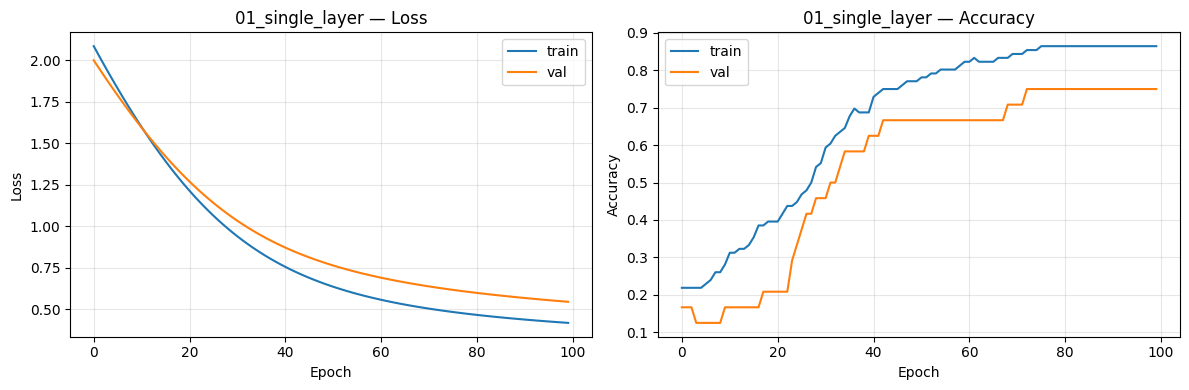

In [6]:
plot_training_curves(history, variant_name='01_single_layer')


## 7. Evaluasi di test set

In [7]:
summary = evaluate_and_report(model, X_test, y_test, variant_name='01_single_layer')
save_history(history, variant_name='01_single_layer')
summary



📊 01_single_layer
   Test loss:     0.5789
   Test accuracy: 0.7667
   Jumlah parameter: 15
✅ History tersimpan di: results/01_single_layer.csv


{'variant': '01_single_layer',
 'test_loss': 0.578898012638092,
 'test_accuracy': 0.7666666507720947,
 'n_params': 15}

## 8. Refleksi singkat
_Diisi oleh anggota yang mengerjakan notebook ini._ Tuliskan jawaban dalam cell markdown di bawah:

1. Berapa total jumlah parameter model ini? Bandingkan dengan varian multi-layer.
2. Menurutmu, apakah model ini cukup ekspresif untuk Iris? Mengapa?
3. Jika dataset diganti dengan yang non-linear separable (mis. XOR), apa prediksimu?


1. Total parameter pada model ini relatif kecil karena hanya terdiri dari satu layer output tanpa hidden layer. Jumlah parameter berasal dari bobot dan bias antara input dan output. Dengan 4 fitur input dan 3 kelas output pada dataset Iris, total parameter = (4 × 3) + 3 = 15 parameter. Jumlah ini jauh lebih sedikit dibandingkan varian multi-layer karena model multi-layer memiliki tambahan bobot dan bias pada hidden layer sehingga kompleksitasnya meningkat.

2. Menurut saya, model ini sudah cukup ekspresif untuk dataset Iris karena sebagian besar kelas pada dataset Iris cukup mudah dipisahkan secara linear, terutama kelas Setosa. Dataset Iris juga memiliki jumlah fitur yang sedikit dan pola data yang tidak terlalu kompleks, sehingga logistic regression atau single-layer network masih dapat mencapai akurasi tinggi. Namun, kemampuan model tetap terbatas untuk menangkap hubungan non-linear yang lebih kompleks dibandingkan model multi-layer.

3. Jika dataset diganti menjadi dataset yang non-linear separable seperti XOR, model ini kemungkinan besar akan gagal memberikan performa yang baik. Hal ini karena single-layer network hanya mampu membuat decision boundary linear, sedangkan XOR membutuhkan boundary non-linear. Untuk menyelesaikan masalah seperti XOR dibutuhkan hidden layer dan fungsi aktivasi non-linear agar model dapat mempelajari pola yang lebih kompleks._Tulis jawabanmu di sini..._